In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)
plt.style.use('default')

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Power BI Updated Data analyst Data.xlsx to Power BI Updated Data analyst Data.xlsx


In [ ]:
df = pd.read_excel("Power BI Updated Data analyst Data.xlsx")
df.head()

,First Name,Email ID,Quantity,Events,Attendee Status,College Name,How did you come to know about this event?,"Specify in ""Others"" (how did you come to know about this event)",Designation,Year of Graduation,City,CGPA,Experience with python (Months),Family Income,Expected salary (Lac),Leadership- skills
0,ANIKET,aniket@xyz.com,1,Art of Resume Building,Attending,D Y PATIL INSTITUTE OF MCA AND MANAGEMENT AKUR...,Email,NaN,Students,2024,Patna,6.7,7,7 Lakh+,6,yes
1,Dhanshree,dhanshree@xyz.com,1,Art of Resume Building,Attending,AP SHAH INSTITUTE OF TECHNOLOGY,Others,College,Students,2024,Amravati,8.2,3,0-2 Lakh,7,no
2,Dhiraj,dhiraj@xyz.com,1,Art of Resume Building,Attending,Don Bosco College of Engineering Fatorda Goa,Email,NaN,Students,2023,Kunrool,6.5,4,5-7 Lakh,7,no
3,Pooja,pooja@xyz.com,1,Art of Resume Building,Attending,Pillai College of Engineering New Panvel,Email,NaN,Students,2025,Tirupati,8.7,7,2-5 Lakh,8,no
4,Aayush,aayush@xyz.com,1,Art of Resume Building,Attending,St Xavier's College,Instagram | LinkedIn | Cloud Counselage Website,NaN,Students,2024,Vijaywada,9.1,3,0-2 Lakh,10,yes


In [ ]:
df.shape

(4894, 16)

In [ ]:
df.isnull().sum()


,0
First Name,0
Email ID,0
Quantity,0
Events,0
Attendee Status,0
College Name,15
How did you come to know about this event?,2216
"Specify in ""Others"" (how did you come to know about this event)",4805
Designation,0
Year of Graduation,0


In [ ]:
# Handle Missing Values

df['Specify in "Others" (how did you come to know about this event)'] = (
    df['Specify in "Others" (how did you come to know about this event)']
    .fillna('Not Specified')
)

df['How did you come to know about this event?'] = (
    df['How did you come to know about this event?']
    .fillna('Not Specified')
)

df['College Name'] = (
    df['College Name']
    .fillna('Not Specified')
)

# Verify missing values
df[
    [
        'Specify in "Others" (how did you come to know about this event)',
        'College Name',
        'How did you come to know about this event?'
    ]
].isnull().sum()


,0
"Specify in ""Others"" (how did you come to know about this event)",0
College Name,0
How did you come to know about this event?,0


In [ ]:
#Q1 How Many unique Students are Present in the Dataset
total_rows = df.shape[0]
unique_students = df['Email ID'].nunique()

total_rows, unique_students


(4894, 2157)

In [ ]:
#how many duplicates are there ??


duplicate_records = total_rows - unique_students
duplicate_records

2737

In [ ]:
# No. Of students entered multiple times

multi_entry_students = (
    df.groupby('Email ID')
    .size()
    .reset_index(name='Entry_Count')
)
multi_entry_students = multi_entry_students[multi_entry_students['Entry_Count'] > 1]

multi_entry_students.shape[0]


1143

In [ ]:
#cleaned Dataset and remove duplicate entries
df.shape
df_clean = df.drop_duplicates(subset='Email ID', keep='first')
df_clean.shape
df_clean['Email ID'].nunique()



2157

In [ ]:
#Q2 What is Average CGPA of Students
avg_cgpa = df_clean['CGPA'].mean()
avg_cgpa
round(avg_cgpa, 2)


np.float64(8.03)

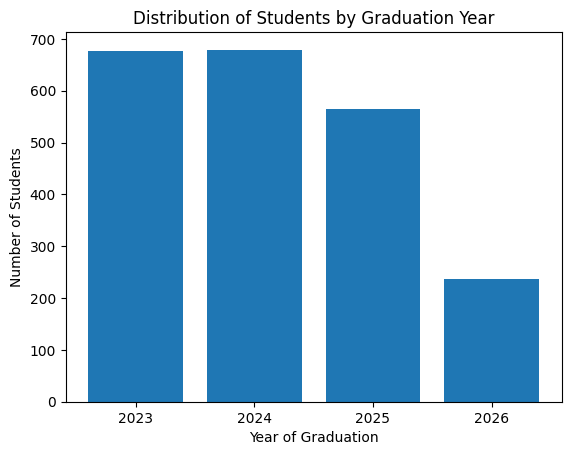

In [ ]:
# Q3. Distribution of students by year of graduation

grad_year_dist = (
    df_clean['Year of Graduation']
    .value_counts()
    .sort_index()
    .reset_index()
)

grad_year_dist.columns = ['Year of Graduation', 'Count']
grad_year_dist

plt.figure()
plt.bar(
    grad_year_dist['Year of Graduation'].astype(str),
    grad_year_dist['Count']
)
plt.title('Distribution of Students by Graduation Year')
plt.xlabel('Year of Graduation')
plt.ylabel('Number of Students')
plt.show()



Total Unique Students: 2157





Python Experience Distribution Table:


/tmp/ipython-input-206/4027755394.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.loc[:, 'Python Experience Level'] = (


,Python Experience Level,Number of Students
2,Beginner (1–3 months),434
0,Basic (4–6 months),1091
1,Intermediate (7–12 months),632


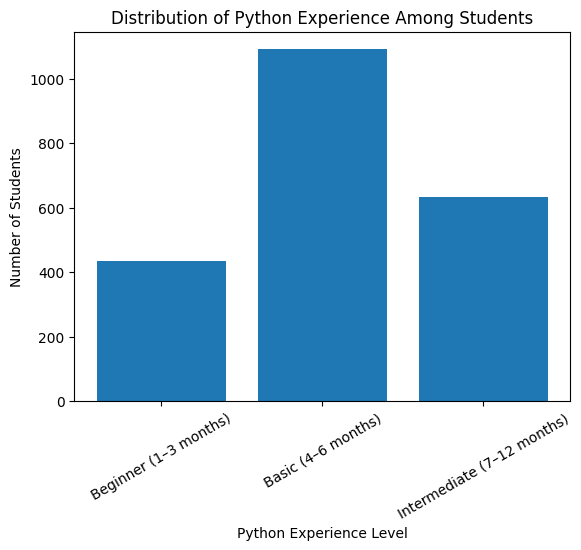

In [ ]:

# Q4: Python Experience Analysis


import matplotlib.pyplot as plt
import pandas as pd

# Total number of unique students
total_students = df_clean.shape[0]
print("Total Unique Students:", total_students)
print("\n")
print("\n")
#  Create Python experience levels (easy to understand)
def python_level(months):
    if months == 0:
        return 'No Experience'
    elif months <= 3:
        return 'Beginner (1–3 months)'
    elif months <= 6:
        return 'Basic (4–6 months)'
    elif months <= 12:
        return 'Intermediate (7–12 months)'
    else:
        return 'Advanced (12+ months)'

df_clean.loc[:, 'Python Experience Level'] = (
    df_clean['Experience with python (Months)'].apply(python_level)
)

#  Create distribution table
python_level_dist = (
    df_clean['Python Experience Level']
    .value_counts()
    .reset_index()
)

python_level_dist.columns = ['Python Experience Level', 'Number of Students']

#  Sort levels logically (important for evaluators)
order = [
    'No Experience',
    'Beginner (1–3 months)',
    'Basic (4–6 months)',
    'Intermediate (7–12 months)',
    'Advanced (12+ months)'
]

python_level_dist['Python Experience Level'] = pd.Categorical(
    python_level_dist['Python Experience Level'],
    categories=order,
    ordered=True
)


python_level_dist = python_level_dist.sort_values('Python Experience Level')

print("\nPython Experience Distribution Table:")
display(python_level_dist)

print("\n")


plt.figure()
plt.bar(
    python_level_dist['Python Experience Level'],
    python_level_dist['Number of Students']
)
plt.title('Distribution of Python Experience Among Students')
plt.xlabel('Python Experience Level')
plt.ylabel('Number of Students')
plt.xticks(rotation=30)
plt.show()


Total Unique Students: 2157
Average Family Income of Students (Approx.): ₹ 131293.46


,Family Income Range,Number of Students
0,0-2 Lakh,2000
1,2-5 Lakh,85
2,7 Lakh+,41
3,5-7 Lakh,31


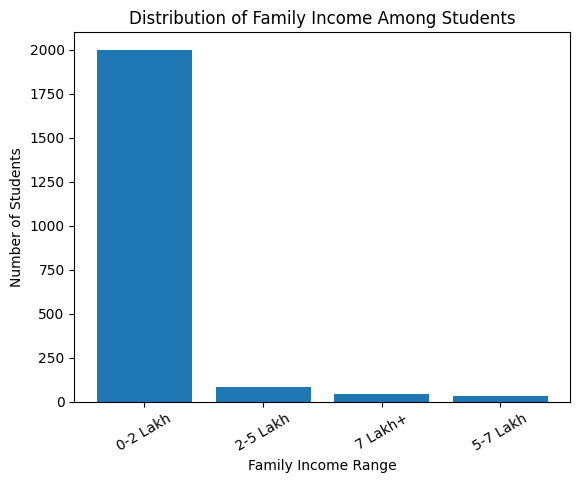

In [ ]:
# Q5 Family Income Analysis
import pandas as pd
import matplotlib.pyplot as plt
import re

df_clean = df_clean.copy()

print("Total Unique Students:", df_clean.shape[0])

def extract_income(text):
    text = str(text).lower()
    nums = re.findall(r'\d+', text)
    nums = [int(n) for n in nums]

    if '0-2' in text:
        return 100000
    if '2-5' in text:
        return 350000
    if '5-7' in text:
        return 600000
    if '7' in text:
        return 850000
    return 100000

df_clean['Income Numeric'] = df_clean['Family Income'].apply(extract_income)

average_income = df_clean['Income Numeric'].mean()

print("Average Family Income of Students (Approx.): ₹", round(average_income, 2))

income_dist = (
    df_clean['Family Income']
    .value_counts()
    .reset_index()
)

income_dist.columns = ['Family Income Range', 'Number of Students']
display(income_dist)

plt.figure()
plt.bar(
    income_dist['Family Income Range'],
    income_dist['Number of Students']
)
plt.title('Distribution of Family Income Among Students')
plt.xlabel('Family Income Range')
plt.ylabel('Number of Students')
plt.xticks(rotation=30)
plt.show()

Top 5 Colleges by Average GPA:



,College Name,Average_GPA
21,St Xavier's College,8.795000
15,New horizon institute of Technology and Manage...,8.611765
3,"B. K. Birla College of Arts, Science & Commerc...",8.566667
2,AP SHAH INSTITUTE OF TECHNOLOGY,8.360000
24,"THAKUR INSTITUTE OF MANAGEMENT STUDIES, CAREER...",8.325000


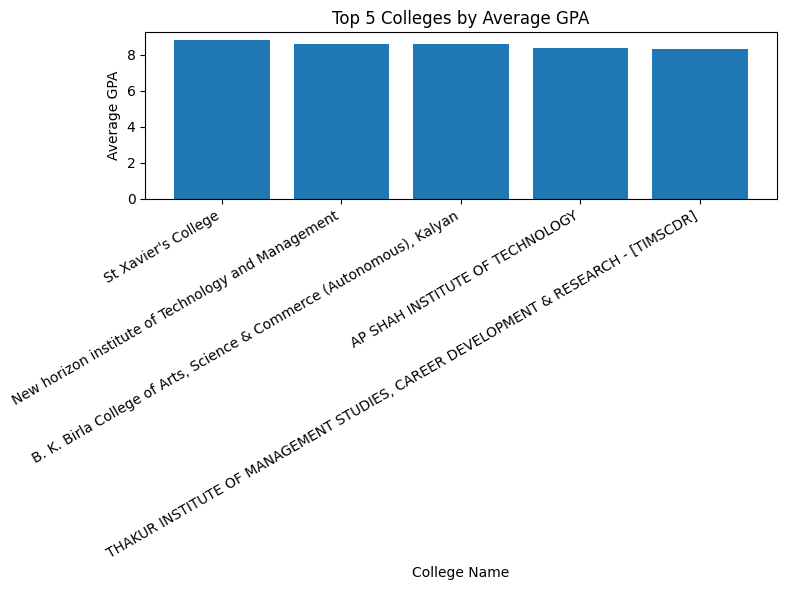

In [ ]:
#Q6: How does the GPA vary among different colleges? (Top 5 only)

import matplotlib.pyplot as plt

df_q6 = df_clean.copy()

df_q6['College Name'] = (
    df_q6['College Name']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

df_q6 = df_q6[df_q6['College Name'].str.lower() != 'nan']
df_q6 = df_q6[df_q6['College Name'] != '']
df_q6 = df_q6.dropna(subset=['College Name', 'CGPA'])

college_gpa = (
    df_q6
    .groupby('College Name', as_index=False)
    .agg(Average_GPA=('CGPA', 'mean'))
    .sort_values(by='Average_GPA', ascending=False)
    .head(5)
)

print("Top 5 Colleges by Average GPA:\n")
display(college_gpa)

plt.figure(figsize=(8,6))
plt.bar(college_gpa['College Name'], college_gpa['Average_GPA'])
plt.xlabel('College Name')
plt.ylabel('Average GPA')
plt.title('Top 5 Colleges by Average GPA')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Lower Bound: 1.0
Upper Bound: 1.0
Number of Outliers: 0


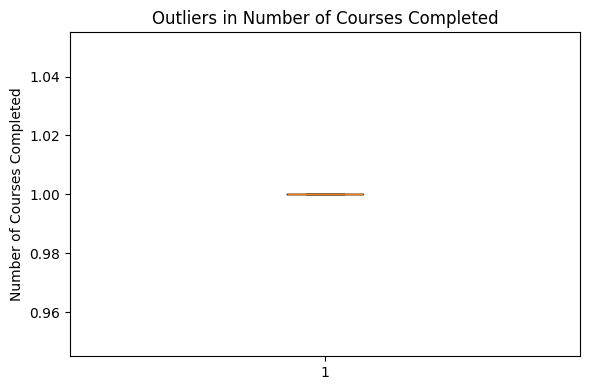

In [ ]:
#Q7 College-wise participation of students


import matplotlib.pyplot as plt

quantity = df_clean['Quantity'].dropna()

q1 = quantity.quantile(0.25)
q3 = quantity.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = quantity[(quantity < lower_bound) | (quantity > upper_bound)]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", outliers.count())

plt.figure(figsize=(6,4))
plt.boxplot(quantity, vert=True)
plt.ylabel('Number of Courses Completed')
plt.title('Outliers in Number of Courses Completed')
plt.tight_layout()
plt.show()


,City,Average_CGPA
40,Delhi,9.014286
132,Raipur,8.980000
156,Sonipat,8.712500
175,konark,8.540000
88,Karnal,8.533333


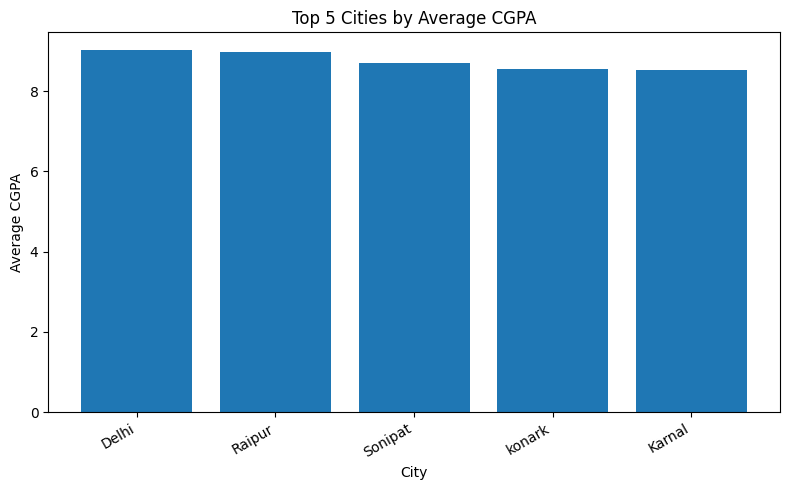

In [ ]:
#Q8. What is the average CGPA for students from each city? (Top 5 cities)
import matplotlib.pyplot as plt

df_q8 = df_clean.copy()

df_q8['City'] = (
    df_q8['City']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

df_q8 = df_q8[df_q8['City'].str.lower() != 'nan']
df_q8 = df_q8[df_q8['City'] != '']
df_q8 = df_q8.dropna(subset=['City', 'CGPA'])

city_cgpa = (
    df_q8
    .groupby('City', as_index=False)
    .agg(Average_CGPA=('CGPA', 'mean'))
    .sort_values(by='Average_CGPA', ascending=False)
    .head(5)
)

display(city_cgpa)

plt.figure(figsize=(8,5))
plt.bar(city_cgpa['City'], city_cgpa['Average_CGPA'])
plt.xlabel('City')
plt.ylabel('Average CGPA')
plt.title('Top 5 Cities by Average CGPA')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

,City,Number of Students
0,Amreli,26
1,Jalor,26
2,Amer,26
3,Mumbai,26
4,Jodhpur,26
5,Jalgaon,25
6,Dhule,24
7,Sangrur,24
8,Thane,24
9,Siuri,24


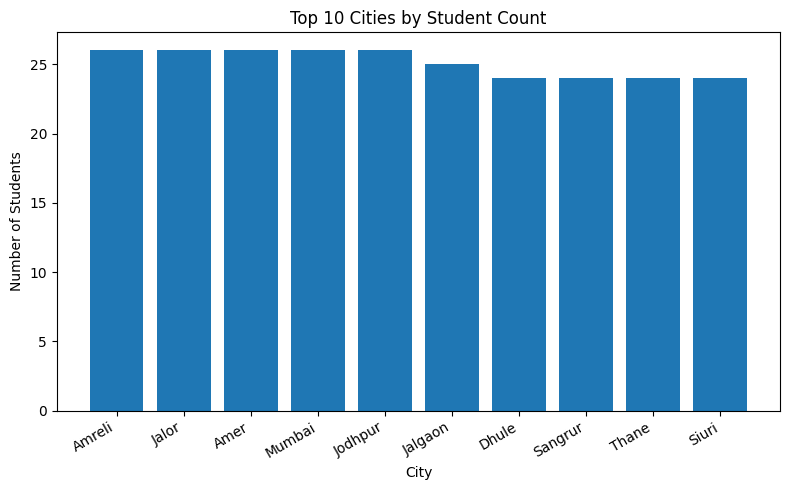

In [ ]:
#Moderate Questions
#Q10 How many students are from various cities?
import matplotlib.pyplot as plt

city_count = (
    df_clean['City']
    .value_counts()
    .reset_index()
)

city_count.columns = ['City', 'Number of Students']

display(city_count.head(10))

plt.figure(figsize=(8,5))
plt.bar(city_count['City'].head(10), city_count['Number of Students'].head(10))
plt.xlabel('City')
plt.ylabel('Number of Students')
plt.title('Top 10 Cities by Student Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


,CGPA,Expected salary (Lac)
0,6.2,8.250000
1,6.3,11.625000
2,6.4,13.520000
3,6.5,12.362500
4,6.6,11.916667


/tmp/ipython-input-206/288705991.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('CGPA Band')['Expected salary (Lac)']


,CGPA Band,Expected salary (Lac)
0,<6,NaN
1,6–7,12.652520
2,7–8,13.271574
3,8–9,12.666667
4,9–10,16.347741


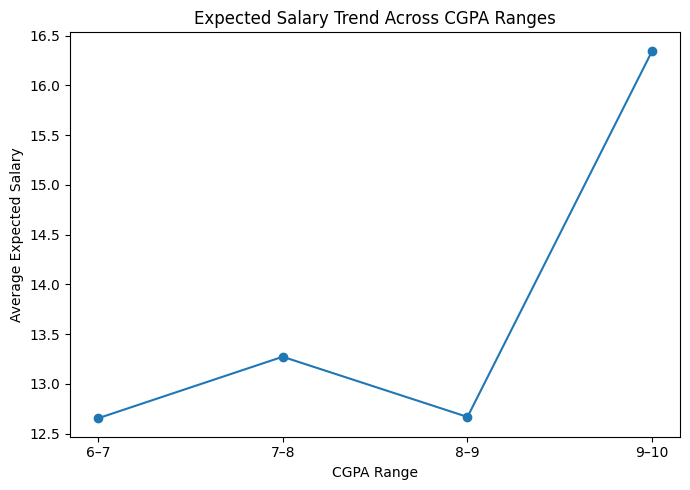

In [ ]:
#Q11 How does expected salary vary based on GPA, Family Income, and Python Experience?

salary_analysis = (
    df_clean
    .groupby(['CGPA'])['Expected salary (Lac)']
    .mean()
    .reset_index()
)

display(salary_analysis.head())
print('\n')
import pandas as pd
import matplotlib.pyplot as plt

df_mod = df_clean.copy()

df_mod['CGPA Band'] = pd.cut(
    df_mod['CGPA'],
    bins=[0, 6, 7, 8, 9, 10],
    labels=['<6', '6–7', '7–8', '8–9', '9–10']
)

salary_cgpa = (
    df_mod
    .groupby('CGPA Band')['Expected salary (Lac)']
    .mean()
    .reset_index()
)

display(salary_cgpa)

plt.figure(figsize=(7,5))
plt.plot(
    salary_cgpa['CGPA Band'].astype(str),
    salary_cgpa['Expected salary (Lac)'],
    marker='o'
)
plt.xlabel('CGPA Range')
plt.ylabel('Average Expected Salary')
plt.title('Expected Salary Trend Across CGPA Ranges')
plt.tight_layout()
plt.show()



,Events,Designation,Number of Students
51,Internship Program(IP) Success Conclave,Students,441
0,Art of Resume Building,Students,336
3,Hello ML and DL,Students,233
2,Data Visualization using Power BI,Students,225
55,Talk on Skill and Employability Enhancement,Students,194
53,Product Marketing,Students,112
8,IAC - Q&A,Students,90
54,Skill and Employability Enhancement,Students,87
56,The Agile Ways of Working,Students,73
1,Artificial Intelligence,Students,62


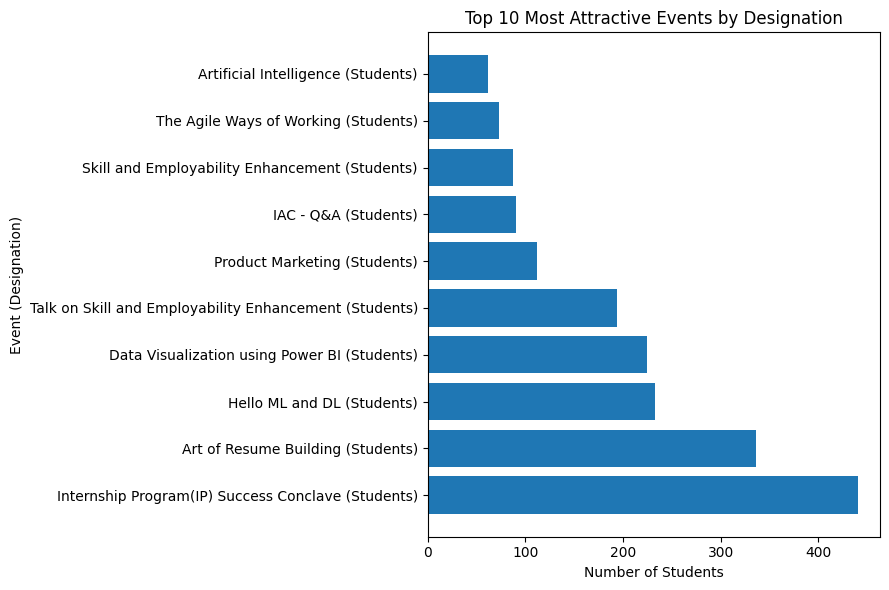

In [ ]:
#Q12 Which event tends to attract more students from specific fields of study?
import pandas as pd
import matplotlib.pyplot as plt

event_designation = (
    df_clean
    .groupby(['Events', 'Designation'])
    .size()
    .reset_index(name='Number of Students')
)

top_10 = (
    event_designation
    .sort_values('Number of Students', ascending=False)
    .head(10)
)

display(top_10)

print('\n')

plt.figure(figsize=(9,6))
plt.barh(
    top_10['Events'] + ' (' + top_10['Designation'] + ')',
    top_10['Number of Students']
)
plt.xlabel('Number of Students')
plt.ylabel('Event (Designation)')
plt.title('Top 10 Most Attractive Events by Designation')
plt.tight_layout()
plt.show()



,Leadership- skills,CGPA,Expected salary (Lac)
0,no,8.04,13.62
1,no,8.01,14.27
2,yes,8.01,13.75


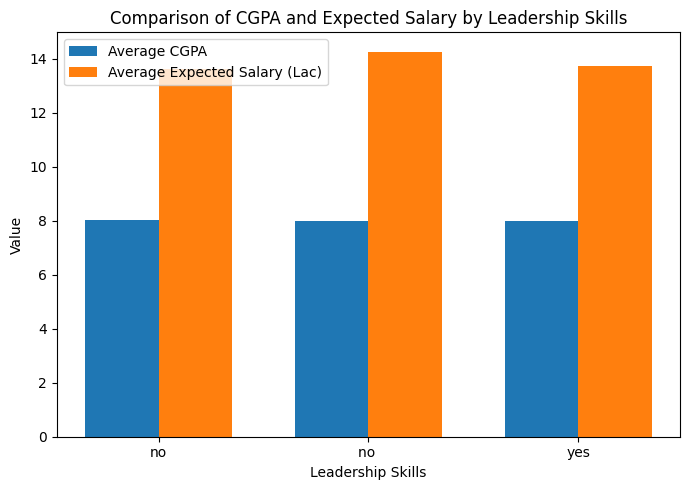

In [ ]:
#Q13  Do students with leadership skills tend to have higher CGPA or higher expected salary?
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

leadership_analysis = (
    df_clean
    .groupby('Leadership- skills')[['CGPA', 'Expected salary (Lac)']]
    .mean()
    .round(2)
    .reset_index()
)

display(leadership_analysis)

x = np.arange(len(leadership_analysis))
width = 0.35

plt.figure(figsize=(7,5))

plt.bar(
    x - width/2,
    leadership_analysis['CGPA'],
    width,
    label='Average CGPA'
)

plt.bar(
    x + width/2,
    leadership_analysis['Expected salary (Lac)'],
    width,
    label='Average Expected Salary (Lac)'
)

plt.xticks(x, leadership_analysis['Leadership- skills'].astype(str))
plt.xlabel('Leadership Skills')
plt.ylabel('Value')
plt.title('Comparison of CGPA and Expected Salary by Leadership Skills')
plt.legend()
plt.tight_layout()
plt.show()


Students graduating by end of 2024: 1355
Students graduating after 2024: 802


,Graduation Period,Number of Students
0,Up to 2024,1355
1,After 2024,802


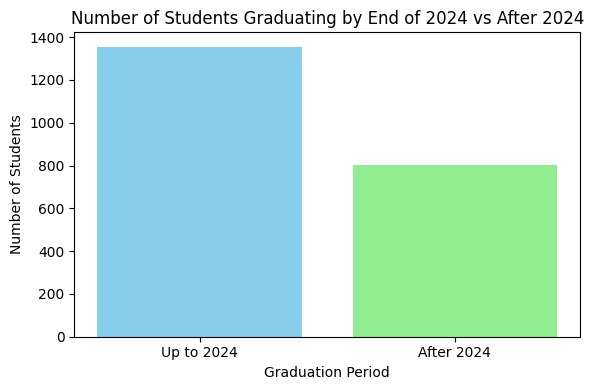

In [ ]:
#Q14 How many students are graduating by the end of 2024?
import pandas as pd
import matplotlib.pyplot as plt

# Count unique students graduating on or before 2024
grad_upto_2024 = df_clean[df_clean['Year of Graduation'] <= 2024].shape[0]

# Count unique students graduating after 2024
grad_after_2024 = df_clean[df_clean['Year of Graduation'] > 2024].shape[0]

print("Students graduating by end of 2024:", grad_upto_2024)
print("Students graduating after 2024:", grad_after_2024)

# Table
grad_counts = pd.DataFrame({
    'Graduation Period': ['Up to 2024', 'After 2024'],
    'Number of Students': [grad_upto_2024, grad_after_2024]
})

display(grad_counts)

print('\n')

# Bar chart
plt.figure(figsize=(6,4))
plt.bar(
    grad_counts['Graduation Period'],
    grad_counts['Number of Students'],
    color=['skyblue', 'lightgreen']
)
plt.title('Number of Students Graduating by End of 2024 vs After 2024')
plt.xlabel('Graduation Period')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()



,Promotion Channel,Number of Students
0,Not Specified,1082
1,Whatsapp,434
2,Email,227
3,Others,89
4,Cloud Counselage Website,64


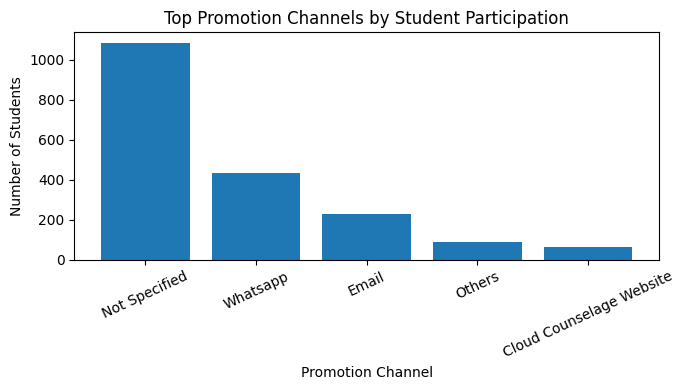

In [ ]:
#Q15. Which promotion channel brings in more student participation for the event?
import pandas as pd
import matplotlib.pyplot as plt

# Clean the promotion channel column
df_clean['How did you come to know about this event?'] = (
    df_clean['How did you come to know about this event?']
    .astype(str)
    .str.strip()
)

# Count students per promotion channel
promotion_count = (
    df_clean['How did you come to know about this event?']
    .value_counts()
    .reset_index()
)

promotion_count.columns = ['Promotion Channel', 'Number of Students']

# Top 5 promotion channels
top_promotion = promotion_count.head(5)

display(top_promotion)

print("\n")

# Bar chart
plt.figure(figsize=(7,4))
plt.bar(
    top_promotion['Promotion Channel'],
    top_promotion['Number of Students']
)
plt.xlabel('Promotion Channel')
plt.ylabel('Number of Students')
plt.title('Top Promotion Channels by Student Participation')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


Total students attended Data Science related events: 225


,Event Name,Number of Students
0,data visualization using power bi,225


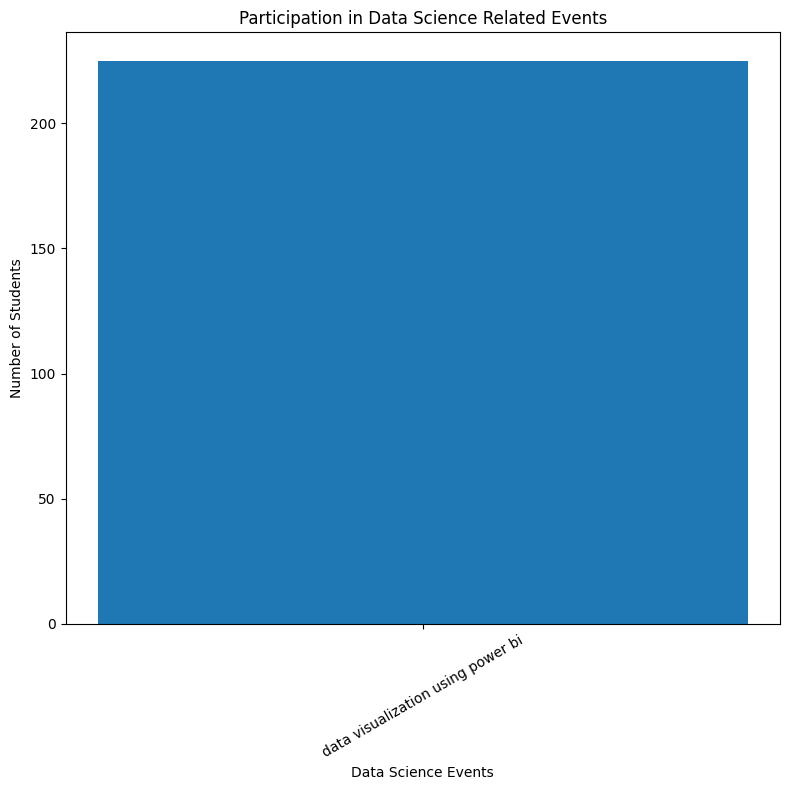

In [ ]:
#Q16. Find the total number of students who attended events related to Data Science
import pandas as pd
import matplotlib.pyplot as plt

# Clean Events column safely
df_clean['Events'] = (
    df_clean['Events']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Filter Data Science related events (robust matching)
data_science_df = df_clean[
    df_clean['Events'].str.contains('data', na=False)
]

# Total students
total_ds_students = data_science_df.shape[0]
print("Total students attended Data Science related events:", total_ds_students)

# Event-wise count
ds_event_count = (
    data_science_df['Events']
    .value_counts()
    .reset_index()
)

ds_event_count.columns = ['Event Name', 'Number of Students']

display(ds_event_count)

print("\n")

# Bar chart
plt.figure(figsize=(8,8))
plt.bar(
    ds_event_count['Event Name'],
    ds_event_count['Number of Students']
)
plt.xlabel('Data Science Events')
plt.ylabel('Number of Students')
plt.title('Participation in Data Science Related Events')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



Average CGPA: 8.03
Average Python Experience (Months): 5.15




,Category,Average Expected Salary (Lac)
0,All Students,13.75
1,High CGPA & High Python Experience Students,16.47


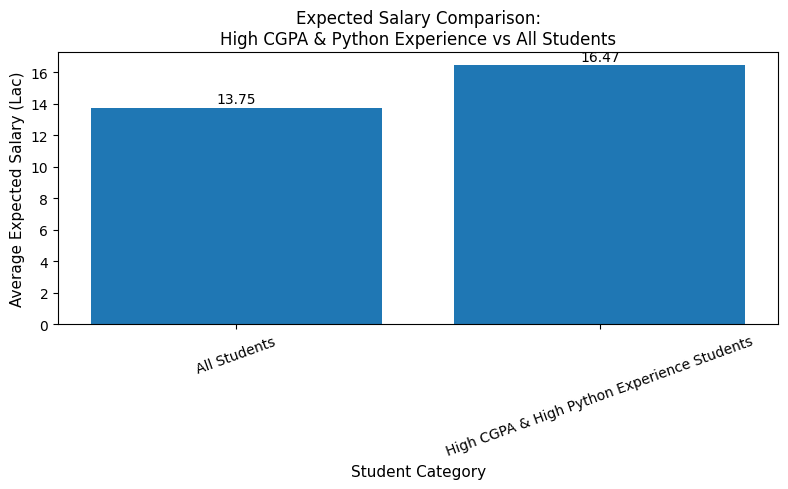

In [ ]:
#Q17 Those who have high CGPA & more experience in Python — do they have higher expected salary? (Average)
import pandas as pd

# Step 1: Calculate averages
avg_cgpa = df_clean['CGPA'].mean()
avg_python_exp = df_clean['Experience with python (Months)'].mean()

print("Average CGPA:", round(avg_cgpa, 2))
print("Average Python Experience (Months):", round(avg_python_exp, 2))
print("\n")

# Step 2: Filter high CGPA + high Python experience students
high_cgpa_python = df_clean[
    (df_clean['CGPA'] >= avg_cgpa) &
    (df_clean['Experience with python (Months)'] >= avg_python_exp)
]

# Step 3: Salary comparison
avg_salary_all = df_clean['Expected salary (Lac)'].mean()
avg_salary_high = high_cgpa_python['Expected salary (Lac)'].mean()

# Step 4: Output
result = pd.DataFrame({
    'Category': [
        'All Students',
        'High CGPA & High Python Experience Students'
    ],
    'Average Expected Salary (Lac)': [
        round(avg_salary_all, 2),
        round(avg_salary_high, 2)
    ]
})

display(result)
print("\n")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))  # Increased figure size

bars = plt.bar(
    result['Category'],
    result['Average Expected Salary (Lac)']
)

plt.xlabel('Student Category', fontsize=11)
plt.ylabel('Average Expected Salary (Lac)', fontsize=11)
plt.title('Expected Salary Comparison:\nHigh CGPA & Python Experience vs All Students', fontsize=12)

plt.xticks(rotation=20)  # Rotate labels slightly for better visibility

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval,2),
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

